In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [9]:
import os
os.chdir(r'C:\Users\Kajal\ML_Projects\Project6_Pdm\Project6_Pdm_\Turbofan engine')

cols = ['unit','cycle','op1','op2','op3'] + [f's{i}' for i in range(1,22)]
df = pd.read_csv('train_FD001.txt', sep='\s+', header=None, names=cols)

print("Shape:", df.shape)
df.head()

Shape: (20631, 26)


,unit,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [10]:
print(df.describe())
print("\nMissing values:", df.isnull().sum().sum())

               unit         cycle           op1           op2      op3  \
count  20631.000000  20631.000000  20631.000000  20631.000000  20631.0   
mean      51.506568    108.807862     -0.000009      0.000002    100.0   
std       29.227633     68.880990      0.002187      0.000293      0.0   
min        1.000000      1.000000     -0.008700     -0.000600    100.0   
25%       26.000000     52.000000     -0.001500     -0.000200    100.0   
50%       52.000000    104.000000      0.000000      0.000000    100.0   
75%       77.000000    156.000000      0.001500      0.000300    100.0   
max      100.000000    362.000000      0.008700      0.000600    100.0   

                 s1            s2            s3            s4            s5  \
count  2.063100e+04  20631.000000  20631.000000  20631.000000  2.063100e+04   
mean   5.186700e+02    642.680934   1590.523119   1408.933782  1.462000e+01   
std    6.537152e-11      0.500053      6.131150      9.000605  3.394700e-12   
min    5.186700e+

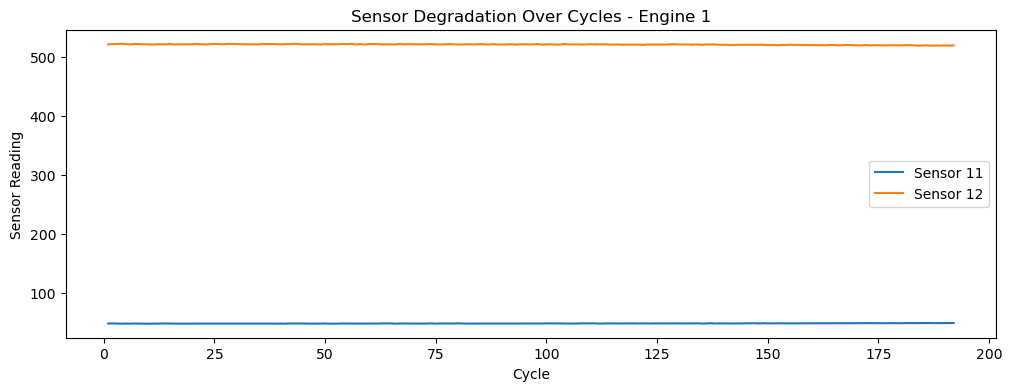

In [11]:
unit1 = df[df['unit'] == 1]
plt.figure(figsize=(12,4))
plt.plot(unit1['cycle'], unit1['s11'], label='Sensor 11')
plt.plot(unit1['cycle'], unit1['s12'], label='Sensor 12')
plt.title('Sensor Degradation Over Cycles - Engine 1')
plt.xlabel('Cycle')
plt.ylabel('Sensor Reading')
plt.legend()
plt.show()

In [12]:
max_cycles = df.groupby('unit')['cycle'].max().reset_index()
max_cycles.columns = ['unit','max_cycle']
df = df.merge(max_cycles, on='unit')
df['RUL'] = df['max_cycle'] - df['cycle']

print("RUL column added!")
df[['unit','cycle','RUL']].head(10)

RUL column added!


,unit,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187
5,1,6,186
6,1,7,185
7,1,8,184
8,1,9,183
9,1,10,182


In [13]:
drop_cols = ['s1','s5','s6','s10','s16','s18','s19',
             'op1','op2','op3','max_cycle']
df.drop(columns=drop_cols, inplace=True)
print("Remaining columns:", df.columns.tolist())

Remaining columns: ['unit', 'cycle', 's2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21', 'RUL']


In [14]:
features = [col for col in df.columns if col.startswith('s')]
X = df[features]
y = df['RUL']

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_scaled, y)
print("Model trained successfully!")

Model trained successfully!


Turbofan RMSE: 15.59


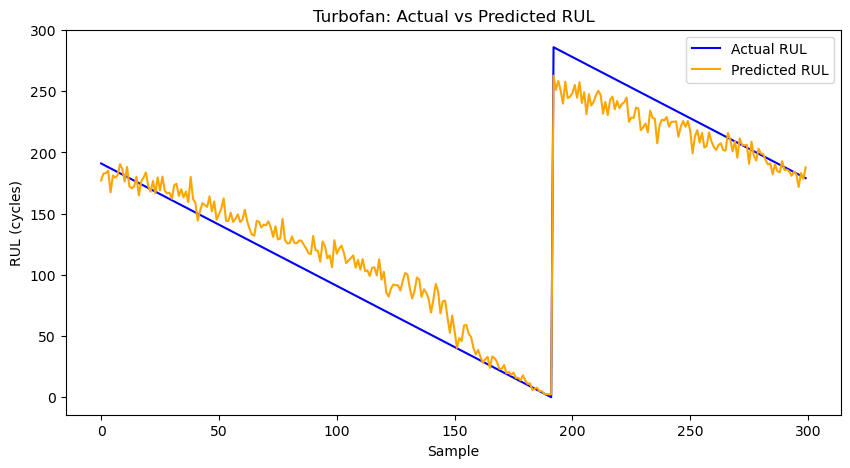

In [15]:
preds = model.predict(X_scaled)
rmse = np.sqrt(mean_squared_error(y, preds))
print(f"Turbofan RMSE: {rmse:.2f}")

plt.figure(figsize=(10,5))
plt.plot(y.values[:300], label='Actual RUL', color='blue')
plt.plot(preds[:300], label='Predicted RUL', color='orange')
plt.title('Turbofan: Actual vs Predicted RUL')
plt.xlabel('Sample')
plt.ylabel('RUL (cycles)')
plt.legend()
plt.show()

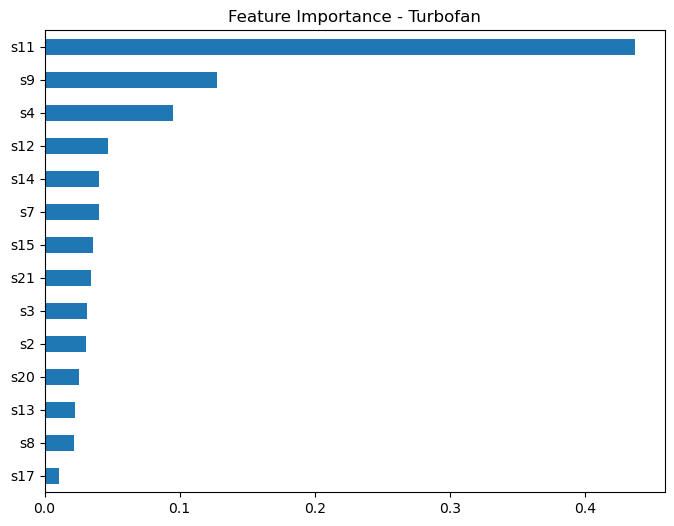

In [16]:
importances = pd.Series(model.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', figsize=(8,6))
plt.title('Feature Importance - Turbofan')
plt.show()